In [5]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Melbourne Urban Microclimate and Pedestrian Activity Analysis</div>
</div>

<div class="usecase-details"><b>Authored by: </b> Harsh Dwivedi</div>
<div class="usecase-details"><b>Date Created: </b> Trimester 1, 2025</div>
<div class="usecase-details"><b>Time to Complete:</b> 120 mins</div>
<div class="usecase-details"><b>Level: </b> Intermediate to Advanced</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b> Python, pandas, data visualisation, and introductory machine learning</div>

<div class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">
Melbourne's urban environment can experience different local climate conditions across locations and times of day. This use case investigates how measured microclimate conditions, urban tree canopy and pedestrian activity vary across the City of Melbourne, and whether environmental conditions are associated with pedestrian counts.

The analysis is intended to help urban planners, researchers and city decision-makers understand where and when warmer conditions occur, how pedestrian activity changes through the day, and whether environmental measurements provide useful information for describing or predicting pedestrian activity.

The source variables are interpreted according to the City of Melbourne datasets. In the pedestrian dataset, <code>pedestriancount</code> is the total hourly sensor count of pedestrians, <code>hourday</code> identifies the hour of day, and <code>sensor_name</code> identifies the counting sensor. In the microclimate dataset, <code>airtemperature</code> is ambient air temperature, <code>relativehumidity</code> is relative humidity, <code>pm25</code> is particulate matter 2.5, and <code>noise</code> is the sensor's noise reading. The 2021 tree-canopy dataset contains mapped canopy polygons representing actual canopy extents on public and private property. Tree counts per spatial grid cell are therefore used only as a proxy for local canopy density in this notebook, not as a direct measure of canopy area.
</div>

<div class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">
This use case demonstrates how to combine City of Melbourne environmental and pedestrian datasets to explore local climate patterns and their relationship with urban activity.

<b>You will learn how to:</b>
<ul>
    <li>Load City of Melbourne Open Data through the Explore API.</li>
    <li>Clean and prepare pedestrian, microclimate and tree-canopy data.</li>
    <li>Visualise spatial and temporal microclimate patterns and pedestrian activity.</li>
    <li>Assess associations and predictive relationships without treating them as causal.</li>
</ul>
</div>

<div class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">
Urban microclimates are local atmospheric conditions that can differ across a city because of built form, vegetation, surface materials and human activity. Melbourne's sensor network provides repeated measurements of temperature, humidity, wind, particulate matter and noise, while the pedestrian counting system records hourly pedestrian movements at selected city locations. Analysing these sources together can help describe when and where environmental conditions and pedestrian activity differ. The analysis is observational: associations, model importance and predictive performance do not by themselves establish that one environmental factor causes changes in pedestrian activity.
</div>

<div class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-datasets">

- [Tree Canopies 2021 (Urban Forest)](https://data.melbourne.vic.gov.au/explore/dataset/tree-canopies-2021-urban-forest/information/)
- [Pedestrian Counting System (counts per hour)](https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/information/)
- [Microclimate sensors data](https://data.melbourne.vic.gov.au/explore/dataset/microclimate-sensors-data/information/)

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Introduction</a><br>
2. <a href="#section-2">Dataset overview and loading</a><br>
3. <a href="#section-3">Data cleaning and preparation</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#subsection-3-1">Missing values, duplicates and counts</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#subsection-3-2">Sensor metrics and outliers</a><br>
4. <a href="#section-4">Feature engineering</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#subsection-4-1">Peak-hour features</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#subsection-4-2">Microclimate features</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.3. <a href="#subsection-4-3">Anomaly and threshold features</a><br>
5. <a href="#section-5">Data integration</a><br>
6. <a href="#section-6">Advanced analysis and visualisation</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#subsection-6-1">Spatial and temporal patterns</a><br>
7. <a href="#section-7">Modelling and forecasting</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.1. <a href="#subsection-7-1">Random Forest regression</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.2. <a href="#subsection-7-2">LSTM time-series forecasting</a>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Introduction</b></div>

<div class="usecase-body">
This analysis investigates how Melbourne's urban microclimate relates to pedestrian activity and whether environmental conditions can help explain variations in pedestrian movement. Combining pedestrian counts with temperature, humidity, air-quality, noise and tree-canopy information allows the analysis to examine when and where environmental conditions coincide with changes in urban activity. This provides evidence that can support understanding of how people experience and use Melbourne's public spaces.
</div>

<div id="section-2" class="usecase-section-heading"><b>2. Dataset overview and loading</b></div>

<div class="usecase-body">
The three datasets provide complementary information needed to address the scenario. Pedestrian counts describe how intensively different locations are used, microclimate sensors describe environmental conditions experienced around the city, and tree-canopy data provides spatial context for urban vegetation. Loading and inspecting these datasets first helps confirm that the required time, location and environmental fields are available before attempting to compare them.
</div>

In [6]:
# Import libraries used throughout the notebook.
import re
from io import StringIO

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from folium.plugins import HeatMap
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential

# Approved MOP plotting palette, in the order defined by the latest template.
MOP_COLOURS = ['#059669', '#9333EA', '#F97316', '#2563EB', '#EAB308', '#EC4899']
MOP_CMAP = LinearSegmentedColormap.from_list('mop_palette', MOP_COLOURS)


In [7]:
# Define one reusable function to retrieve a complete City of Melbourne dataset export.
def collect_data(dataset_id):
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    url = f'{base_url}{dataset_id}/exports/csv'
    params = {
        'select': '*',
        'limit': -1,
        'lang': 'en',
        'timezone': 'Australia/Melbourne'
    }

    # Request the CSV export and stop with a clear error if the request fails.
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()

    # Parse the semicolon-delimited export into a pandas DataFrame.
    return pd.read_csv(StringIO(response.content.decode('utf-8')), delimiter=';')


In [8]:
# Load the 2021 tree-canopy dataset and inspect its structure.
df_trees = collect_data('tree-canopies-2021-urban-forest')
print(f'The tree canopy dataset contains {len(df_trees):,} records.')
display(df_trees.head(3))
print('Tree canopy columns:', df_trees.columns.tolist())

# Load hourly pedestrian counts and inspect the fields used later in the analysis.
df_pedestrians = collect_data('pedestrian-counting-system-monthly-counts-per-hour')
print(f'\nThe pedestrian dataset contains {len(df_pedestrians):,} records.')
display(df_pedestrians.head(3))
print('Pedestrian columns:', df_pedestrians.columns.tolist())

# Load microclimate sensor readings and inspect the available environmental measurements.
df_climate = collect_data('microclimate-sensors-data')
print(f'\nThe microclimate dataset contains {len(df_climate):,} records.')
display(df_climate.head(3))
print('Microclimate columns:', df_climate.columns.tolist())


The tree canopy dataset contains 57,980 records.


,geo_point_2d,geo_shape
0,"-37.795401772079884, 144.9578491713787","{""coordinates"": [[[[144.95785054828673, -37.79..."
1,"-37.79535552368289, 144.9514339834316","{""coordinates"": [[[[144.95143147647892, -37.79..."
2,"-37.79569214657717, 144.97057737168868","{""coordinates"": [[[[144.9705639020907, -37.795..."


Tree canopy columns: ['geo_point_2d', 'geo_shape']

The pedestrian dataset contains 1,619,370 records.


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,2220260901,2,2026-09-01,2,7,7,14,Bou283_T,"-37.81380668, 144.96516718"
1,19220260901,19,2026-09-01,2,1,5,6,LtB210_T,"-37.81237202, 144.96550671"
2,184020260901,184,2026-09-01,0,21,23,44,Eli124_T,"-37.81512416, 144.96371988"


Pedestrian columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']

The microclimate dataset contains 989,186 records.


,device_id,received_at,sensorlocation,latlong,minimumwinddirection,averagewinddirection,maximumwinddirection,minimumwindspeed,averagewindspeed,gustwindspeed,airtemperature,relativehumidity,atmosphericpressure,pm25,pm10,noise
0,ICTMicroclimate-03,2023-05-18T16:09:52+10:00,CH1 rooftop,"-37.8140348, 144.96728",179.0,200.0,211.0,1.3,1.5,2.8,12.4,68.2,1016.7,1.0,3.0,87.7
1,ICTMicroclimate-03,2023-05-18T15:39:49+10:00,CH1 rooftop,"-37.8140348, 144.96728",124.0,172.0,179.0,0.9,1.4,3.9,12.6,66.5,1016.6,1.0,3.0,76.7
2,ICTMicroclimate-03,2023-05-18T15:24:47+10:00,CH1 rooftop,"-37.8140348, 144.96728",153.0,191.0,225.0,1.2,2.2,3.4,12.9,63.1,1016.7,1.0,3.0,77.0


Microclimate columns: ['device_id', 'received_at', 'sensorlocation', 'latlong', 'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection', 'minimumwindspeed', 'averagewindspeed', 'gustwindspeed', 'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25', 'pm10', 'noise']


<div class="usecase-body">Before cleaning, missing-cell totals are recorded for each dataset. This provides a baseline for understanding which sources require additional preparation.</div>

In [9]:
# Summarise missing cells before any cleaning so later decisions are traceable.
print('\n--- Missing Value Summary ---')
print('Tree Canopy:', df_trees.isnull().sum().sum(), 'missing cells')
print('Pedestrians:', df_pedestrians.isnull().sum().sum(), 'missing cells')
print('Climate:', df_climate.isnull().sum().sum(), 'missing cells')



--- Missing Value Summary ---
Tree Canopy: 0 missing cells
Pedestrians: 47364 missing cells
Climate: 884709 missing cells


<div id="section-3" class="usecase-section-heading"><b>3. Data cleaning and preparation</b></div>

<div class="usecase-body">
Reliable comparisons require the datasets to use consistent and valid values. Missing records, duplicates, incorrect data types and extreme measurements can distort temporal patterns or create misleading relationships between environmental conditions and pedestrian activity. This stage therefore prepares a more reliable foundation for the later analysis rather than treating every raw observation as equally trustworthy.
</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1 Missing values, duplicates and counts</b></div>

<div class="usecase-body">
Missing values and duplicate records are examined to understand the completeness of each dataset before analysis. This is important because gaps or repeated observations could artificially change pedestrian totals or environmental averages. Identifying these issues helps determine which records can be used reliably in later comparisons.
</div>

In [10]:
# Create working copies so the source DataFrames remain unchanged.
df_trees_clean = df_trees.copy()
df_pedestrians_clean = df_pedestrians.copy()
df_climate_clean = df_climate.copy()

# Standardise column names without changing the underlying field meanings.
for frame in (df_trees_clean, df_pedestrians_clean, df_climate_clean):
    frame.columns = frame.columns.str.strip().str.replace(' ', '_', regex=False)

# Parse the pedestrian date so later time-based features can be created reliably.
df_pedestrians_clean.loc[:, 'sensing_date'] = pd.to_datetime(
    df_pedestrians_clean['sensing_date'], errors='coerce'
)

# Remove exact duplicate pedestrian records and keep an explicit independent copy.
pedestrian_duplicates = df_pedestrians_clean.duplicated().sum()
if pedestrian_duplicates:
    df_pedestrians_clean = df_pedestrians_clean.drop_duplicates().copy()
print(f'Pedestrian duplicates removed: {pedestrian_duplicates:,}')

# Parse microclimate timestamps and convert them to Melbourne local time.
df_climate_clean.loc[:, 'received_at'] = pd.to_datetime(
    df_climate_clean['received_at'], errors='coerce', utc=True
).dt.tz_convert('Australia/Melbourne').dt.tz_localize(None)

# Remove duplicate readings recorded by the same device at the same timestamp.
climate_duplicates = df_climate_clean.duplicated(
    subset=['device_id', 'received_at']
).sum()
if climate_duplicates:
    df_climate_clean = df_climate_clean.drop_duplicates(
        subset=['device_id', 'received_at']
    ).copy()
else:
    df_climate_clean = df_climate_clean.copy()

print(f'Microclimate duplicate timestamps removed: {climate_duplicates:,}')


Pedestrian duplicates removed: 0
Microclimate duplicate timestamps removed: 2,766


<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2 Sensor metrics and outliers</b></div>

<div class="usecase-body">
Microclimate sensor measurements are checked for missing values and unusually extreme readings before they are compared with pedestrian activity. Sensor errors or isolated extreme values could otherwise create relationships that do not represent typical urban conditions. Treating these issues carefully makes the later environmental comparisons more meaningful.
</div>

In [11]:
# Work on an explicit independent DataFrame before filling sensor values.
df_climate_clean = df_climate_clean.copy()

# Check missingness in the key microclimate measurements used later in the analysis.
key_metrics = ['airtemperature', 'relativehumidity', 'pm25', 'noise']
for metric in key_metrics:
    missing_pct = df_climate_clean[metric].isna().mean() * 100
    print(f'Missing values in {metric}: {missing_pct:.2f}%')

    # Fill gaps only when fewer than 30% of observations are missing for that metric.
    # Filling is performed within each device so values are not carried between sensors.
    if missing_pct < 30:
        filled_values = df_climate_clean.groupby('device_id')[metric].transform(
            lambda series: series.ffill().bfill()
        )
        df_climate_clean.loc[:, metric] = filled_values

# Calculate interquartile-range (IQR) bounds for air temperature.
q1 = df_climate_clean['airtemperature'].quantile(0.25)
q3 = df_climate_clean['airtemperature'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Count temperature observations outside the IQR bounds before capping them.
outlier_count = (
    (df_climate_clean['airtemperature'] < lower_bound) |
    (df_climate_clean['airtemperature'] > upper_bound)
).sum()

# Cap extreme values while preserving the number of observations in the dataset.
df_climate_clean.loc[:, 'airtemperature'] = df_climate_clean['airtemperature'].clip(
    lower_bound, upper_bound
)
print(
    f'Air-temperature values capped outside {lower_bound:.2f}°C to '
    f'{upper_bound:.2f}°C: {outlier_count:,}'
)


Missing values in airtemperature: 1.60%
Missing values in relativehumidity: 1.60%
Missing values in pm25: 8.40%
Missing values in noise: 8.40%
Air-temperature values capped outside 2.15°C to 29.75°C: 24,477


<div id="section-4" class="usecase-section-heading"><b>4. Feature engineering</b></div>

<div class="usecase-body">
The raw datasets do not directly contain all of the information needed to investigate the scenario. Additional temporal and environmental features are therefore created to represent concepts such as peak pedestrian periods, perceived heat and unusual weather conditions. These features make it possible to examine the data in terms that are more directly connected to how environmental conditions and pedestrian activity vary across Melbourne.
</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1 Peak-hour features</b></div>

<div class="usecase-body">
Pedestrian timestamps are reconstructed from <code>sensing_date</code> and <code>hourday</code>, and additional features describe moving activity levels, percentage changes and each sensor's busiest average hour. Identifying recurring busy periods helps show when public spaces experience the greatest pedestrian demand and provides a useful basis for examining whether those periods coincide with particular microclimate conditions.
</div>

In [12]:
# Start from the cleaned pedestrian data so the original source data remains unchanged.
df_pedestrians_enhanced = df_pedestrians_clean.copy()

# Ensure the source date column is stored as a proper datetime type.
df_pedestrians_enhanced['sensing_date'] = pd.to_datetime(
    df_pedestrians_enhanced['sensing_date'],
    errors='coerce'
)

# Ensure hourday is numeric before using it to construct timestamps.
df_pedestrians_enhanced['hourday'] = pd.to_numeric(
    df_pedestrians_enhanced['hourday'],
    errors='coerce'
)

# Remove rows where the required date or hour could not be parsed.
df_pedestrians_enhanced = df_pedestrians_enhanced.dropna(
    subset=['sensing_date', 'hourday']
).copy()

# Reconstruct a complete hourly timestamp from the source date and hour fields.
df_pedestrians_enhanced['date_hour'] = (
    df_pedestrians_enhanced['sensing_date']
    + pd.to_timedelta(df_pedestrians_enhanced['hourday'], unit='h')
)

# Derive calendar and time-of-day indicators for recurring pedestrian patterns.
df_pedestrians_enhanced['day_of_week'] = (
    df_pedestrians_enhanced['sensing_date'].dt.dayofweek
)

df_pedestrians_enhanced['weekend'] = (
    df_pedestrians_enhanced['day_of_week'] >= 5
).astype(int)

df_pedestrians_enhanced['time_of_day'] = pd.cut(
    df_pedestrians_enhanced['hourday'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

# Sort observations chronologically within each pedestrian sensor before rolling calculations.
df_pedestrians_enhanced = df_pedestrians_enhanced.sort_values(
    ['sensor_name', 'date_hour']
)

# Calculate a seven-observation moving average to smooth short-term fluctuations.
df_pedestrians_enhanced['pedestrian_count_ma7'] = (
    df_pedestrians_enhanced
    .groupby('sensor_name')['pedestriancount']
    .transform(
        lambda series: series.rolling(
            window=7,
            min_periods=1
        ).mean()
    )
)

# Calculate percentage change relative to the previous observation
# for the same sensor and hour.
df_pedestrians_enhanced['pedestrian_count_pct_change'] = (
    df_pedestrians_enhanced
    .groupby(['sensor_name', 'hourday'])['pedestriancount']
    .pct_change() * 100
)

# Find the hour with the highest average pedestrian count for each sensor.
hourly_average = (
    df_pedestrians_enhanced
    .groupby(['sensor_name', 'hourday'])['pedestriancount']
    .mean()
    .reset_index()
)

peak_hours = hourly_average.loc[
    hourly_average
    .groupby('sensor_name')['pedestriancount']
    .idxmax(),
    ['sensor_name', 'hourday']
].rename(
    columns={'hourday': 'peak_hour'}
)

# Attach each sensor's peak hour and flag observations occurring during that hour.
df_pedestrians_enhanced = df_pedestrians_enhanced.merge(
    peak_hours,
    on='sensor_name',
    how='left'
)

df_pedestrians_enhanced['is_peak_hour'] = (
    df_pedestrians_enhanced['hourday']
    == df_pedestrians_enhanced['peak_hour']
).astype(int)

print(
    'Pedestrian enhanced columns:',
    df_pedestrians_enhanced.columns.tolist()
)

Pedestrian enhanced columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location', 'date_hour', 'day_of_week', 'weekend', 'time_of_day', 'pedestrian_count_ma7', 'pedestrian_count_pct_change', 'peak_hour', 'is_peak_hour']


<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2 Microclimate features</b></div>

<div class="usecase-body">
Microclimate timestamps are separated into calendar features, while temperature and relative humidity are combined into a simple heat-index estimate. These features help compare environmental conditions across different times and provide a more meaningful indication of how outdoor conditions may be experienced by pedestrians than temperature alone.
</div>

In [13]:
def calculate_heat_index(temperature, humidity):
    # Return a simple feels-like temperature estimate in degrees Celsius.
    if pd.isna(temperature) or pd.isna(humidity):
        return np.nan

    # Convert to Fahrenheit because this approximation is expressed in °F.
    temp_f = (temperature * 9 / 5) + 32

    heat_index_f = 0.5 * (
        temp_f
        + 61.0
        + ((temp_f - 68.0) * 1.2)
        + (humidity * 0.094)
    )

    return (heat_index_f - 32) * 5 / 9


# Start from the cleaned climate data before creating derived variables.
df_climate_enhanced = df_climate_clean.copy()

# Convert the timestamp column to datetime before using .dt operations.
df_climate_enhanced['received_at'] = pd.to_datetime(
    df_climate_enhanced['received_at'],
    errors='coerce'
)

# Remove rows where the timestamp could not be parsed.
df_climate_enhanced = df_climate_enhanced.dropna(
    subset=['received_at']
).copy()

# Extract calendar fields from each microclimate sensor timestamp.
df_climate_enhanced['year'] = (
    df_climate_enhanced['received_at'].dt.year
)

df_climate_enhanced['month'] = (
    df_climate_enhanced['received_at'].dt.month
)

df_climate_enhanced['day'] = (
    df_climate_enhanced['received_at'].dt.day
)

df_climate_enhanced['hour'] = (
    df_climate_enhanced['received_at'].dt.hour
)

df_climate_enhanced['day_of_week'] = (
    df_climate_enhanced['received_at'].dt.dayofweek
)

df_climate_enhanced['weekend'] = (
    df_climate_enhanced['day_of_week'] >= 5
).astype(int)

# Ensure climate measurements are numeric before calculating heat index.
df_climate_enhanced['airtemperature'] = pd.to_numeric(
    df_climate_enhanced['airtemperature'],
    errors='coerce'
)

df_climate_enhanced['relativehumidity'] = pd.to_numeric(
    df_climate_enhanced['relativehumidity'],
    errors='coerce'
)

# Derive the heat-index approximation from air temperature and relative humidity.
df_climate_enhanced['heat_index'] = df_climate_enhanced.apply(
    lambda row: calculate_heat_index(
        row['airtemperature'],
        row['relativehumidity']
    ),
    axis=1
)

print('Microclimate time and heat-index features created.')

Microclimate time and heat-index features created.


<div id="subsection-4-3" class="usecase-sub-section-heading"><b>4.3 Anomaly and threshold features</b></div>

<div class="usecase-body">
Temperature anomalies and hot, cold and high-humidity indicators identify observations that differ from typical conditions for each device. These features are useful because pedestrian behaviour may respond differently during unusually uncomfortable conditions than during normal weather. They therefore provide another way to explore whether changes in the urban environment coincide with changes in pedestrian activity.
</div>

In [14]:
# Calculate each device's average air temperature for each calendar day.
daily_average = df_climate_enhanced.groupby(
    ['device_id', 'year', 'month', 'day']
)['airtemperature'].transform('mean')

# Express each observation as a deviation from that device's daily average temperature.
df_climate_enhanced['temperature_anomaly'] = (
    df_climate_enhanced['airtemperature'] - daily_average
)

# Create descriptive threshold indicators for hot, cold and high-humidity conditions.
df_climate_enhanced['is_hot_day'] = (
    df_climate_enhanced['airtemperature'] > 30
).astype(int)
df_climate_enhanced['is_cold_day'] = (
    df_climate_enhanced['airtemperature'] < 15
).astype(int)
df_climate_enhanced['is_high_humidity'] = (
    df_climate_enhanced['relativehumidity'] > 70
).astype(int)

# Inspect the newly engineered climate fields before data integration.
feature_columns = [
    'temperature_anomaly', 'is_hot_day', 'is_cold_day', 'is_high_humidity'
]
display(df_climate_enhanced[feature_columns].head())


,temperature_anomaly,is_hot_day,is_cold_day,is_high_humidity
0,1.55625,0,1,0
1,1.75625,0,1,0
2,2.05625,0,1,0
3,2.05625,0,1,0
4,1.95625,0,1,0


<div id="section-5" class="usecase-section-heading"><b>5. Data integration</b></div>

<div class="usecase-body">
Pedestrian and microclimate observations must be aligned in time before their relationship can be examined meaningfully. Microclimate measurements are therefore summarised hourly and matched with pedestrian observations occurring within a comparable time window. This creates a combined dataset in which pedestrian activity and environmental conditions can be examined together, directly supporting the scenario's question of whether changes in the urban environment are associated with changes in pedestrian movement.
</div>

In [15]:
def integrate_datasets(df_pedestrians_enhanced, df_climate_enhanced):
    # Match pedestrian observations to the nearest hourly microclimate summary.
    pedestrians = df_pedestrians_enhanced.copy()
    climate = df_climate_enhanced.copy()

    # Aggregate the 15-minute climate readings to one city-wide hourly summary.
    climate_hourly = (
        climate.groupby(climate['received_at'].dt.floor('h'))
        .agg(
            airtemperature=('airtemperature', 'mean'),
            relativehumidity=('relativehumidity', 'mean'),
            pm25=('pm25', 'mean'),
            noise=('noise', 'mean'),
            heat_index=('heat_index', 'mean')
        )
        .reset_index()
        .rename(columns={'received_at': 'date_hour'})
    )

    # Match only observations with a climate record within one hour.
    merged = pd.merge_asof(
        pedestrians.sort_values('date_hour'),
        climate_hourly.sort_values('date_hour'),
        on='date_hour',
        direction='nearest',
        tolerance=pd.Timedelta('1h')
    )

    # Report descriptive correlations only for rows with overlapping climate measurements.
    overlap = merged.dropna(subset=['airtemperature', 'relativehumidity', 'pm25', 'noise'])
    print(f'Integrated rows: {len(merged):,}')
    print(f'Rows with matched climate measurements: {len(overlap):,}')
    for metric in ['airtemperature', 'relativehumidity', 'pm25', 'noise', 'heat_index']:
        correlation = overlap['pedestriancount'].corr(overlap[metric])
        print(f'Correlation between pedestrian count and {metric}: {correlation:.4f}')

    return merged


# Integrate the enhanced datasets and display only a compact sample.
merged_df = integrate_datasets(df_pedestrians_enhanced, df_climate_enhanced)
display(merged_df.head())


# The full integrated table is no longer required after this summary.
# Release it before modelling to reduce peak notebook memory use.
del merged_df


Integrated rows: 1,619,370
Rows with matched climate measurements: 1,619,178
Correlation between pedestrian count and airtemperature: 0.1917
Correlation between pedestrian count and relativehumidity: -0.2251
Correlation between pedestrian count and pm25: -0.0176
Correlation between pedestrian count and noise: 0.2339
Correlation between pedestrian count and heat_index: 0.1834


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,date_hour,...,time_of_day,pedestrian_count_ma7,pedestrian_count_pct_change,peak_hour,is_peak_hour,airtemperature,relativehumidity,pm25,noise,heat_index
0,108020240902,108,2024-09-02,0,1,20,21,261Will_T,"-37.81295822, 144.95678789",2024-09-02,...,Night,21.0,NaN,8.0,0,17.970968,48.254839,1.516129,80.112903,17.083608
1,51020240902,51,2024-09-02,0,11,3,14,Fra118_T,"-37.80841815, 144.95906316",2024-09-02,...,Night,14.0,NaN,12.0,0,17.970968,48.254839,1.516129,80.112903,17.083608
2,12020240902,12,2024-09-02,0,2,8,10,NewQ_T,"-37.81457988, 144.94292398",2024-09-02,...,Night,10.0,NaN,17.0,0,17.970968,48.254839,1.516129,80.112903,17.083608
3,71020240902,71,2024-09-02,0,8,2,10,WestWP_T,"-37.81235775, 144.97136962",2024-09-02,...,Night,10.0,NaN,12.0,0,17.970968,48.254839,1.516129,80.112903,17.083608
4,69020240902,69,2024-09-02,0,2,1,3,FLDegC_T,"-37.81687226, 144.96559144",2024-09-02,...,Night,3.0,NaN,12.0,0,17.970968,48.254839,1.516129,80.112903,17.083608


<div id="section-6" class="usecase-section-heading"><b>6. Advanced analysis and visualisation</b></div>

<div class="usecase-body">
The combined data is explored visually and statistically to identify patterns that may not be apparent from individual records. Examining environmental conditions, pedestrian activity and tree canopy across time and space helps reveal when and where differences occur and provides context for deciding which relationships are worth investigating further.
</div>

<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1 Spatial and temporal patterns</b></div>

<div class="usecase-body">
Spatial and temporal visualisations are used to compare how microclimate conditions and pedestrian activity vary across Melbourne. This helps identify busy periods, warmer locations and areas with different levels of tree-canopy coverage. These patterns are useful for understanding whether the environment surrounding public spaces may be associated with how those spaces are used.
</div>

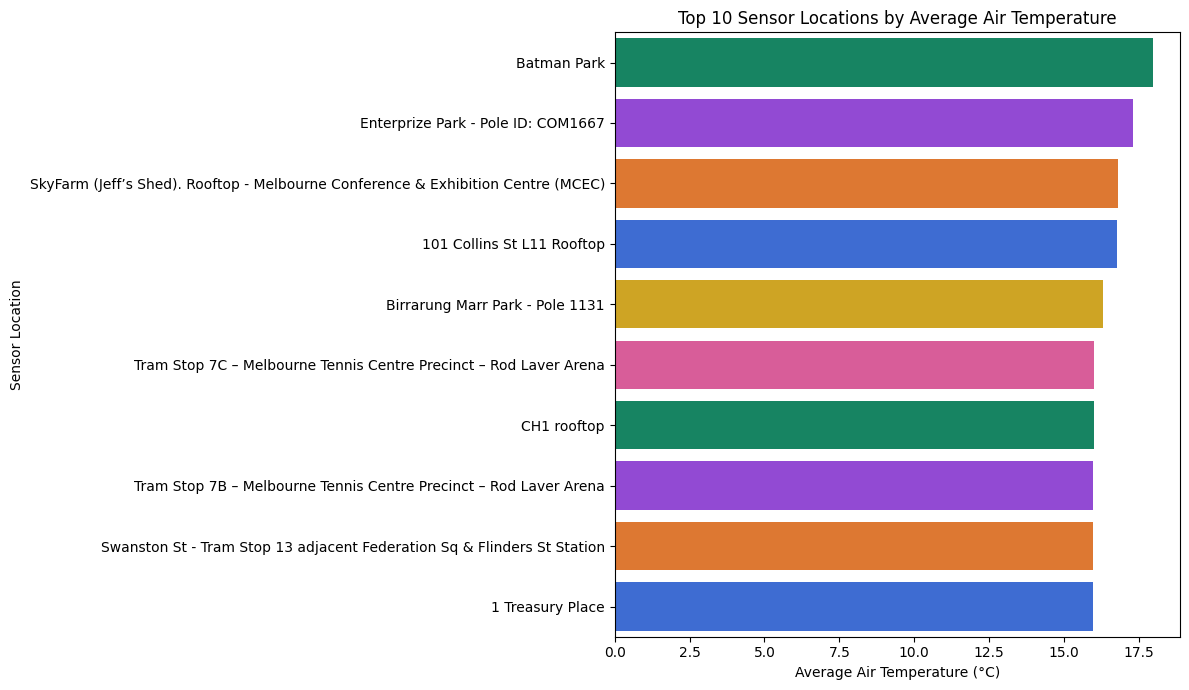

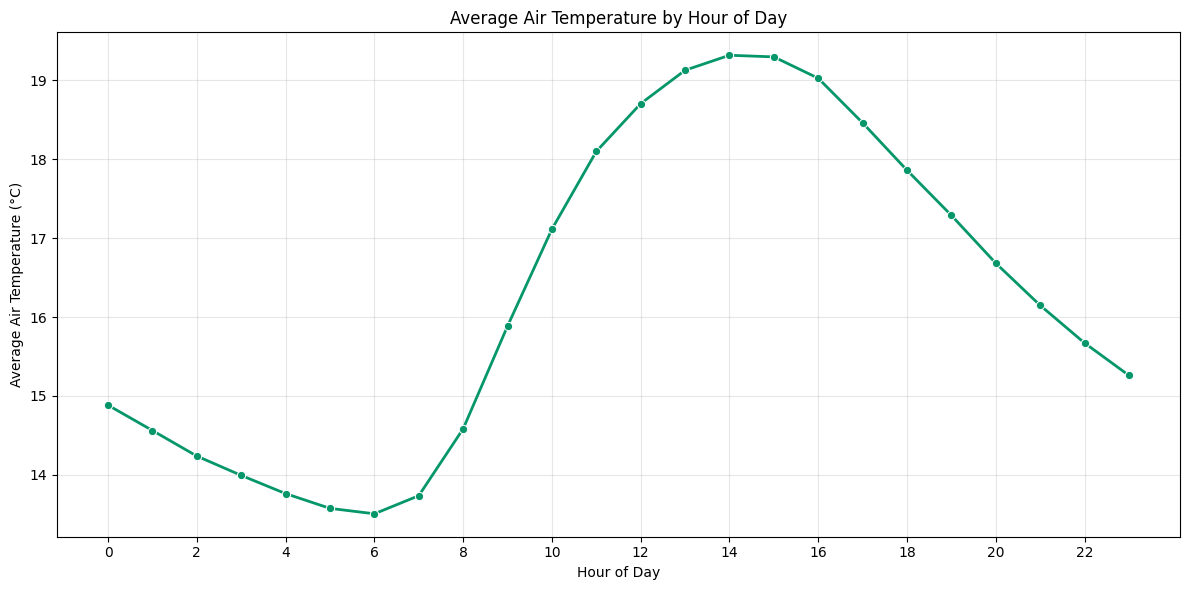

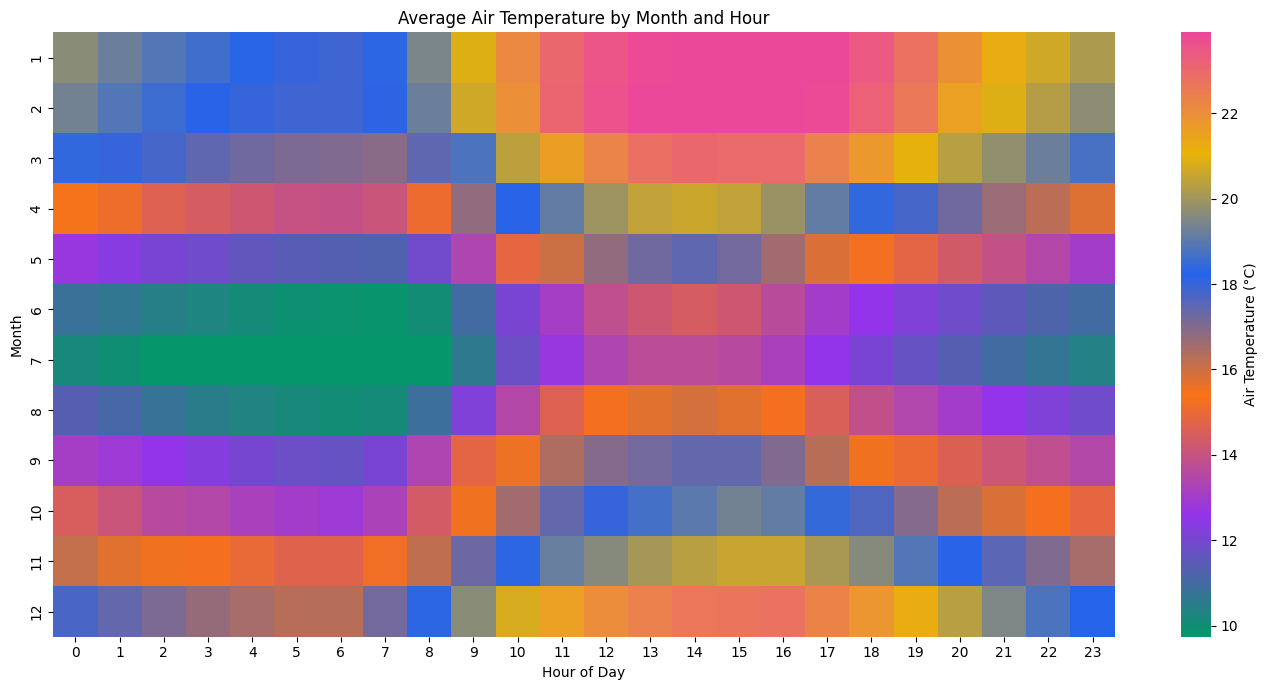

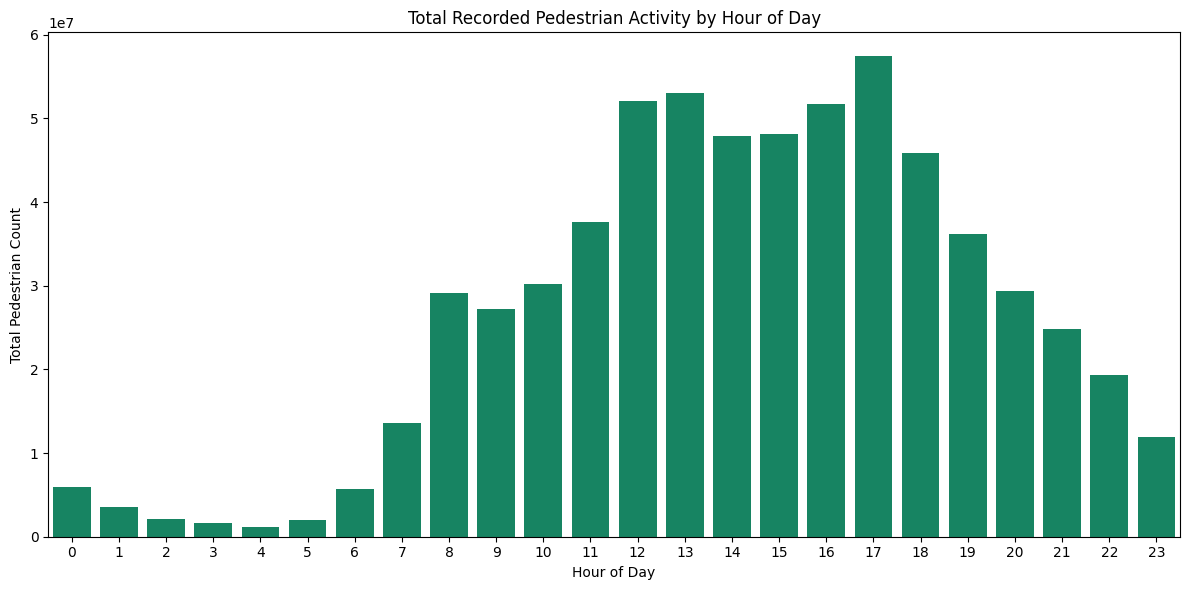

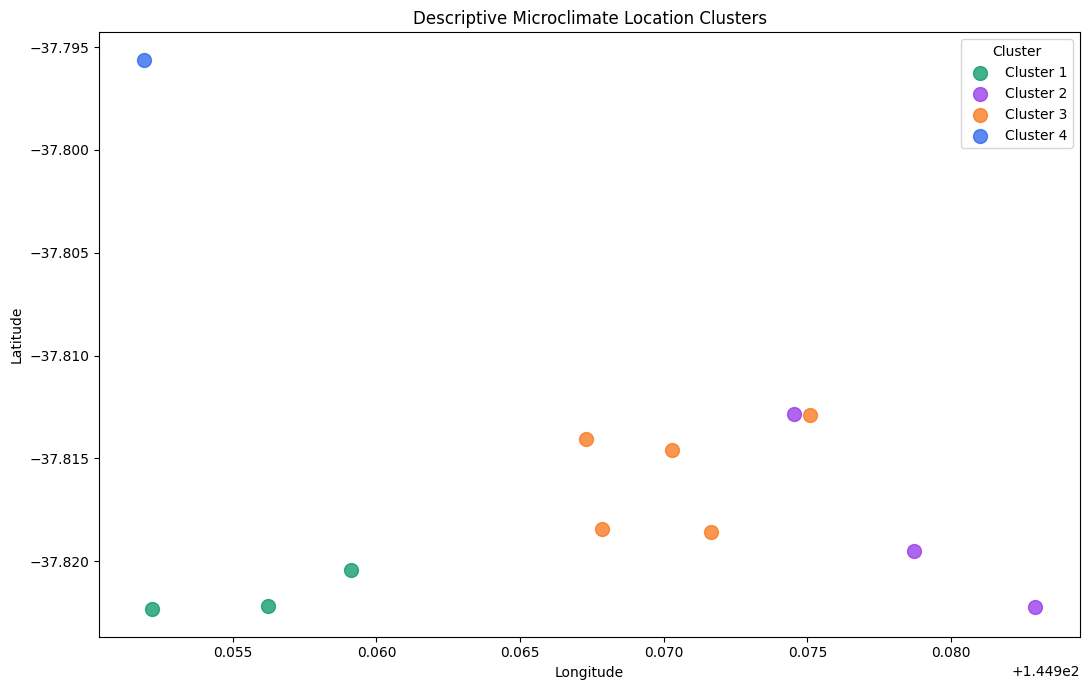

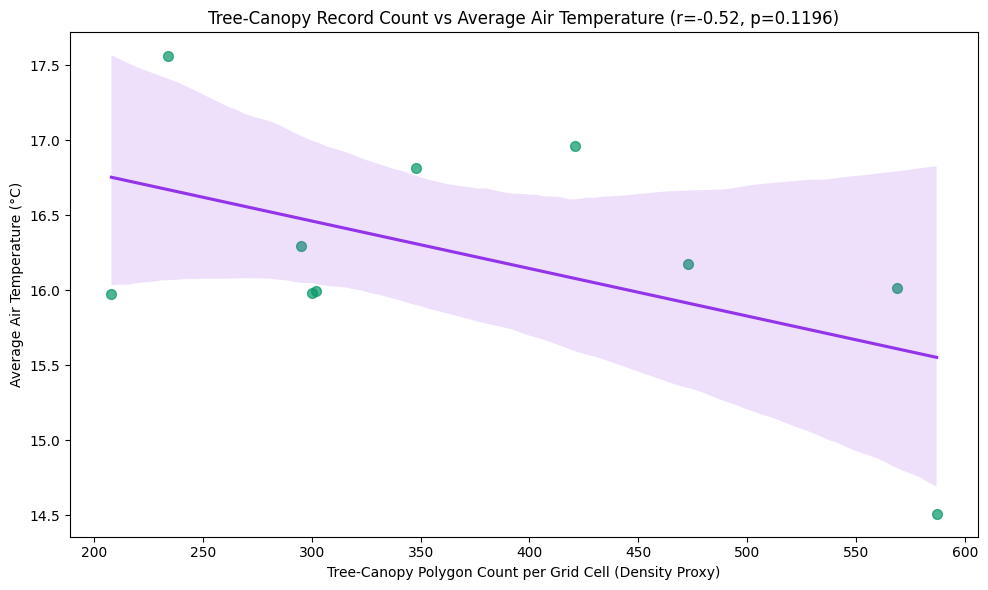

In [16]:
def prepare_spatial_fields(df_trees, df_climate):
    # Extract latitude and longitude values used by the spatial visualisations.
    trees = df_trees.copy()
    climate = df_climate.copy()

    # Parse tree-canopy coordinates from the portal's geo_point_2d field.
    tree_coords = trees['geo_point_2d'].astype(str).str.extract(
        r'(?P<latitude>-?\d+\.\d+)\s*,\s*(?P<longitude>-?\d+\.\d+)'
    )
    trees[['latitude', 'longitude']] = tree_coords.astype(float)

    # Parse microclimate coordinates from the latlong field.
    climate_coords = climate['latlong'].astype(str).str.extract(
        r'(?P<latitude>-?\d+\.\d+)\s*,\s*(?P<longitude>-?\d+\.\d+)'
    )
    climate[['latitude', 'longitude']] = climate_coords.astype(float)
    return trees, climate


# Prepare spatial fields once for all maps and location-based plots.
trees_plot, climate_plot = prepare_spatial_fields(df_trees_clean, df_climate_enhanced)


def create_temperature_heatmap(df_climate):
    # Map measured air temperatures across microclimate sensor locations.
    valid = df_climate.dropna(subset=['latitude', 'longitude', 'airtemperature'])
    melbourne_map = folium.Map(
        location=[-37.815, 144.965], zoom_start=13, tiles='CartoDB positron'
    )

    # Sample large sensor tables for responsive rendering without changing measurements.
    sample = valid.sample(min(10000, len(valid)), random_state=42)
    heat_data = sample[['latitude', 'longitude', 'airtemperature']].values.tolist()

    # Apply the approved MOP colours in order; omit deprecated max_val.
    HeatMap(
        heat_data,
        radius=15,
        gradient={
            0.25: MOP_COLOURS[0],
            0.50: MOP_COLOURS[1],
            0.75: MOP_COLOURS[2],
            1.00: MOP_COLOURS[3]
        },
        min_opacity=0.5,
        blur=15
    ).add_to(melbourne_map)
    return melbourne_map


def analyze_temperature_by_location(df_climate):
    # Compare average air temperature across sensor locations.
    top_locations = (
        df_climate.groupby('sensorlocation', dropna=True)['airtemperature']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name='mean_temperature')
    )

    # Give each category one explicit colour so Seaborn does not cycle an undersized palette.
    location_colours = [
        MOP_COLOURS[index % len(MOP_COLOURS)]
        for index in range(len(top_locations))
    ]
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=top_locations,
        y='sensorlocation',
        x='mean_temperature',
        hue='sensorlocation',
        hue_order=top_locations['sensorlocation'].tolist(),
        palette=location_colours,
        legend=False
    )
    plt.title('Top 10 Sensor Locations by Average Air Temperature')
    plt.xlabel('Average Air Temperature (°C)')
    plt.ylabel('Sensor Location')
    plt.tight_layout()
    plt.show()


def analyze_temperature_by_time(df_climate):
    # Summarise the daily temperature cycle across all available sensor readings.
    hourly = df_climate.groupby('hour', as_index=False)['airtemperature'].mean()

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=hourly, x='hour', y='airtemperature',
        marker='o', linewidth=2, color=MOP_COLOURS[0]
    )
    plt.title('Average Air Temperature by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Air Temperature (°C)')
    plt.xticks(range(0, 24, 2))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def create_temporal_heatmap(df_climate):
    # Compare average air temperature by calendar month and hour.
    temporal = df_climate.pivot_table(
        index='month', columns='hour', values='airtemperature', aggfunc='mean'
    )

    plt.figure(figsize=(14, 7))
    ax = sns.heatmap(temporal, cmap=MOP_CMAP, robust=True)
    plt.title('Average Air Temperature by Month and Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Month')
    ax.collections[0].colorbar.set_label('Air Temperature (°C)')
    plt.tight_layout()
    plt.show()


def analyze_pedestrian_activity(df_pedestrians):
    # Sum recorded pedestrian movements for each hour of day.
    hourly_counts = (
        df_pedestrians.groupby('hourday', as_index=False)['pedestriancount'].sum()
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=hourly_counts,
        x='hourday',
        y='pedestriancount',
        color=MOP_COLOURS[0]
    )
    plt.title('Total Recorded Pedestrian Activity by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Total Pedestrian Count')
    plt.tight_layout()
    plt.show()


def microclimate_clustering(df_climate):
    # Group sensor locations descriptively using location and mean air temperature.
    location_data = (
        df_climate.dropna(subset=['latitude', 'longitude', 'airtemperature'])
        .groupby(['latitude', 'longitude'], as_index=False)['airtemperature']
        .mean()
    )
    if len(location_data) < 3:
        return

    # Standardise inputs so latitude, longitude and temperature have comparable scales.
    features = location_data[['latitude', 'longitude', 'airtemperature']]
    features_std = (features - features.mean()) / features.std()
    n_clusters = min(4, len(location_data))
    location_data['cluster'] = KMeans(
        n_clusters=n_clusters, random_state=42, n_init=10
    ).fit_predict(features_std)

    # Plot each cluster with the next approved MOP colour.
    plt.figure(figsize=(11, 7))
    for cluster_id in sorted(location_data['cluster'].unique()):
        subset = location_data[location_data['cluster'] == cluster_id]
        plt.scatter(
            subset['longitude'],
            subset['latitude'],
            s=100,
            alpha=0.75,
            label=f'Cluster {cluster_id + 1}',
            color=MOP_COLOURS[cluster_id]
        )
    plt.title('Descriptive Microclimate Location Clusters')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()


def analyze_canopy_temperature(df_trees, df_climate):
    # Compare tree-canopy polygon counts with air temperature in coarse grid cells.
    lat_bins = np.arange(-37.830, -37.800 + 0.005, 0.005)
    lon_bins = np.arange(144.950, 144.980 + 0.005, 0.005)

    # Keep only rows with valid spatial and temperature information.
    trees = df_trees.dropna(
        subset=['latitude', 'longitude']
    ).copy()

    climate = df_climate.dropna(
        subset=['latitude', 'longitude', 'airtemperature']
    ).copy()

    # Ensure spatial fields are numeric.
    trees['latitude'] = pd.to_numeric(
        trees['latitude'],
        errors='coerce'
    )
    trees['longitude'] = pd.to_numeric(
        trees['longitude'],
        errors='coerce'
    )

    climate['latitude'] = pd.to_numeric(
        climate['latitude'],
        errors='coerce'
    )
    climate['longitude'] = pd.to_numeric(
        climate['longitude'],
        errors='coerce'
    )
    climate['airtemperature'] = pd.to_numeric(
        climate['airtemperature'],
        errors='coerce'
    )

    # Remove any values that failed numeric conversion.
    trees = trees.dropna(
        subset=['latitude', 'longitude']
    ).copy()

    climate = climate.dropna(
        subset=['latitude', 'longitude', 'airtemperature']
    ).copy()

    # Assign tree-canopy records to approximate 500 m grid cells.
    tree_lat_bin = pd.Series(
        np.digitize(trees['latitude'].to_numpy(), lat_bins),
        index=trees.index
    )

    tree_lon_bin = pd.Series(
        np.digitize(trees['longitude'].to_numpy(), lon_bins),
        index=trees.index
    )

    trees['grid_cell'] = (
        tree_lat_bin.astype(str)
        + '_'
        + tree_lon_bin.astype(str)
    )

    # Assign climate readings to the same approximate grid cells.
    climate_lat_bin = pd.Series(
        np.digitize(climate['latitude'].to_numpy(), lat_bins),
        index=climate.index
    )

    climate_lon_bin = pd.Series(
        np.digitize(climate['longitude'].to_numpy(), lon_bins),
        index=climate.index
    )

    climate['grid_cell'] = (
        climate_lat_bin.astype(str)
        + '_'
        + climate_lon_bin.astype(str)
    )

    # Use polygon record count only as a proxy for canopy density, not canopy area.
    tree_counts = (
        trees.groupby('grid_cell')
        .size()
        .reset_index(name='tree_count')
    )

    temperatures = (
        climate.groupby(
            'grid_cell',
            as_index=False
        )['airtemperature']
        .mean()
    )

    # Match canopy-density proxy with average temperature.
    grid_data = tree_counts.merge(
        temperatures,
        on='grid_cell',
        how='inner'
    )

    # Require enough matched grid cells for a meaningful correlation.
    if len(grid_data) <= 5:
        print(
            'Not enough matched grid cells for canopy-temperature correlation.'
        )
        return None

    # Pearson r measures linear association.
    correlation, p_value = pearsonr(
        grid_data['tree_count'],
        grid_data['airtemperature']
    )

    plt.figure(figsize=(10, 6))

    sns.regplot(
        data=grid_data,
        x='tree_count',
        y='airtemperature',
        scatter_kws={
            'alpha': 0.7,
            's': 50,
            'color': MOP_COLOURS[0]
        },
        line_kws={
            'color': MOP_COLOURS[1]
        }
    )

    plt.title(
        'Tree-Canopy Record Count vs Average Air Temperature '
        f'(r={correlation:.2f}, p={p_value:.4f})'
    )

    plt.xlabel(
        'Tree-Canopy Polygon Count per Grid Cell (Density Proxy)'
    )
    plt.ylabel('Average Air Temperature (°C)')

    plt.tight_layout()
    plt.show()

    return correlation, p_value


# Generate each visualisation separately so its purpose and output remain clear.
temperature_map = create_temperature_heatmap(climate_plot)
display(temperature_map)

analyze_temperature_by_location(climate_plot)
analyze_temperature_by_time(climate_plot)
create_temporal_heatmap(climate_plot)
analyze_pedestrian_activity(df_pedestrians_enhanced)
microclimate_clustering(climate_plot)
canopy_correlation = analyze_canopy_temperature(trees_plot, climate_plot)


<div class="usecase-body">
The visualisations show clear spatial and temporal variation in Melbourne’s microclimate and pedestrian activity. Temperature differs across sensor locations and hours of the day, while pedestrian counts show strong time-of-day patterns. The clustering and tree-canopy analysis provide additional descriptive context, but these patterns should be interpreted as associations rather than causal relationships.
</div>

<div id="section-7" class="usecase-section-heading"><b>7. Modelling and forecasting</b></div>

<div class="usecase-body">
The descriptive analysis shows patterns and associations, but modelling provides a further test of whether those patterns contain useful predictive information. Two approaches are used: Random Forest regression examines whether environmental measurements help predict hourly pedestrian counts, while the LSTM model tests whether recent pedestrian activity can help forecast future activity. Together, they examine the scenario from both environmental and temporal perspectives.
</div>

<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1 Random Forest regression</b></div>

<div class="usecase-body">
Random Forest regression is used to test whether air temperature, relative humidity, PM2.5 and noise contain useful information for predicting pedestrian activity. This directly supports the scenario by moving beyond visual association and measuring how well environmental conditions can explain unseen pedestrian counts. A held-out test set is used so performance is assessed on observations that were not used to train the model.
</div>

In [17]:
# Keep only the fields required for modelling.
pedestrian_model_data = df_pedestrians_clean[
    ['sensing_date', 'hourday', 'pedestriancount']
].copy()

# Convert source fields to the correct types.
pedestrian_model_data['sensing_date'] = pd.to_datetime(
    pedestrian_model_data['sensing_date'],
    errors='coerce'
)

pedestrian_model_data['hourday'] = pd.to_numeric(
    pedestrian_model_data['hourday'],
    errors='coerce'
)

pedestrian_model_data['pedestriancount'] = pd.to_numeric(
    pedestrian_model_data['pedestriancount'],
    errors='coerce'
)

# Remove invalid pedestrian rows before building timestamps.
pedestrian_model_data = pedestrian_model_data.dropna(
    subset=['sensing_date', 'hourday', 'pedestriancount']
).copy()

# Build exact hourly timestamps.
pedestrian_model_data['date_hour'] = (
    pedestrian_model_data['sensing_date']
    + pd.to_timedelta(
        pedestrian_model_data['hourday'],
        unit='h'
    )
)

# Keep only climate fields required for modelling.
climate_model_data = df_climate_clean[
    ['received_at', 'airtemperature', 'relativehumidity', 'pm25', 'noise']
].copy()

# Convert received_at before using .dt.
climate_model_data['received_at'] = pd.to_datetime(
    climate_model_data['received_at'],
    errors='coerce'
)

# Convert climate measurements to numeric.
for column in ['airtemperature', 'relativehumidity', 'pm25', 'noise']:
    climate_model_data[column] = pd.to_numeric(
        climate_model_data[column],
        errors='coerce'
    )

# Remove invalid climate rows.
climate_model_data = climate_model_data.dropna(
    subset=[
        'received_at',
        'airtemperature',
        'relativehumidity',
        'pm25',
        'noise'
    ]
).copy()

# Floor climate timestamps to hourly resolution.
climate_model_data['date_hour'] = (
    climate_model_data['received_at'].dt.floor('h')
)

# Aggregate climate readings to hourly resolution.
climate_model_data = (
    climate_model_data
    .groupby('date_hour', as_index=False)
    .agg(
        airtemperature=('airtemperature', 'mean'),
        relativehumidity=('relativehumidity', 'mean'),
        pm25=('pm25', 'mean'),
        noise=('noise', 'mean')
    )
)

# Match pedestrian observations to the nearest hourly climate record.
model_data = pd.merge_asof(
    pedestrian_model_data.sort_values('date_hour'),
    climate_model_data.sort_values('date_hour'),
    on='date_hour',
    direction='nearest',
    tolerance=pd.Timedelta('1h')
)

# Remove rows missing modelling values.
model_data = model_data.dropna(
    subset=[
        'airtemperature',
        'relativehumidity',
        'pm25',
        'noise',
        'pedestriancount'
    ]
).copy()

print(f'Available matched observations: {len(model_data):,}')

# Use a reproducible sample to prevent excessive memory use.
MAX_MODEL_ROWS = 100_000

if len(model_data) > MAX_MODEL_ROWS:
    model_data = model_data.sample(
        n=MAX_MODEL_ROWS,
        random_state=42
    ).copy()

print(f'Observations used for modelling: {len(model_data):,}')

# Separate predictors and target.
features = [
    'airtemperature',
    'relativehumidity',
    'pm25',
    'noise'
]

X = model_data[features].copy()
y = model_data['pedestriancount'].copy()

# Hold out 20% for evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train a memory-efficient Random Forest.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Generate predictions.
y_pred = rf_model.predict(X_test)

# Evaluate the model.
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

median_ae = median_absolute_error(
    y_test,
    y_pred
)

print(f'RMSE: {rmse:.2f} pedestrians')
print(f'R²: {r2:.3f}')
print(f'MAE: {mae:.2f} pedestrians')
print(f'Median absolute error: {median_ae:.2f} pedestrians')

Available matched observations: 1,619,370
Observations used for modelling: 100,000
RMSE: 534.00 pedestrians
R²: 0.148
MAE: 331.48 pedestrians
Median absolute error: 203.77 pedestrians


<div class="usecase-body">
The Random Forest achieved an RMSE of 534.00 pedestrians, an MAE of 331.48 pedestrians and an R² of 0.148 on the held-out test data. The R² value indicates that the selected environmental variables explain approximately 14.8% of the variation in pedestrian counts, suggesting that microclimate conditions provide some predictive information but do not explain most of the variation in pedestrian activity. Other factors, such as location, time of day, events and surrounding land use, are therefore likely to play an important role. These results describe predictive relationships and should not be interpreted as evidence of causation.
</div>

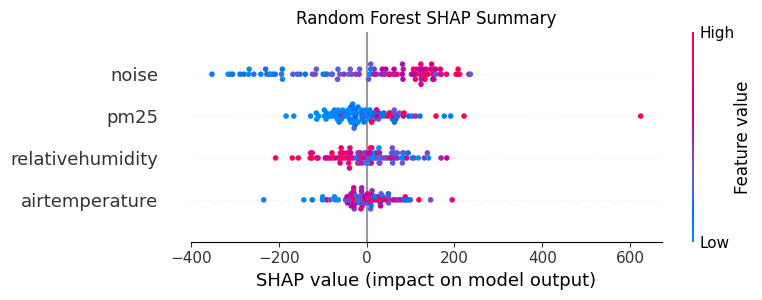

In [18]:
# Confirm that the Random Forest model has already been trained.
if 'rf_model' not in globals():
    raise RuntimeError(
        "Random Forest model not found. Run the model-training section before this SHAP cell."
    )

# Use the available modelling feature set.
# Prefer X_train, but fall back to X_test if necessary.
if 'X_train' in globals():
    X_shap_source = X_train.copy()
elif 'X_test' in globals():
    X_shap_source = X_test.copy()
else:
    raise RuntimeError(
        "No modelling feature data found. Run the train/test split and "
        "Random Forest training cells before this SHAP section."
    )

# Use a small reproducible sample to keep SHAP computation manageable.
background_size = min(100, len(X_shap_source))
sample_size = min(100, len(X_shap_source))

X_background = X_shap_source.sample(
    n=background_size,
    random_state=42
)

X_sample = X_shap_source.sample(
    n=sample_size,
    random_state=42
)

# Explain the fitted Random Forest model.
explainer = shap.Explainer(
    rf_model,
    X_background
)

shap_values_sample = explainer(X_sample)

# SHAP values describe model influence, not causal effects.
shap.summary_plot(
    shap_values_sample,
    X_sample,
    color=MOP_CMAP,
    show=False
)

plt.title('Random Forest SHAP Summary')
plt.tight_layout()
plt.show()

<div class="usecase-body">
Model performance alone does not show which environmental conditions are most influential. SHAP values are therefore used to examine how strongly individual environmental features contribute to the Random Forest predictions. This makes the model easier to interpret and helps identify which microclimate measurements are most relevant to its estimates of pedestrian activity, without treating those relationships as causal.
</div>

<div id="subsection-7-2" class="usecase-sub-section-heading"><b>7.2 LSTM time-series forecasting</b></div>

<div class="usecase-body">
Pedestrian activity may also depend strongly on its own recent history rather than environmental conditions alone. The LSTM model therefore uses the previous 30 days of pedestrian counts to forecast the next daily value. This provides a complementary view of the scenario by testing whether recurring temporal patterns can be used to anticipate future pedestrian demand.
</div>

In [19]:
# Select one pedestrian sensor so the time series represents a consistent location.
sensor_data = (
    df_pedestrians_clean[df_pedestrians_clean['sensor_name'] == 'Col12_T']
    [['sensing_date', 'pedestriancount']]
    .sort_values('sensing_date')
    .set_index('sensing_date')
    .resample('D')
    .sum()
    .ffill()
)

# Scale daily counts to 0-1 before fitting the neural network.
scaler = MinMaxScaler()
scaled = scaler.fit_transform(sensor_data[['pedestriancount']])


# Convert the daily series into 30-day input windows and next-day targets.
def create_sequences(data, sequence_length):
    X_sequences, y_targets = [], []
    for index in range(len(data) - sequence_length):
        X_sequences.append(data[index:index + sequence_length])
        y_targets.append(data[index + sequence_length])
    return np.array(X_sequences), np.array(y_targets)


sequence_length = 30
X_sequence, y_sequence = create_sequences(scaled, sequence_length)

# Preserve chronological order, holding out the final 20% of sequences.
split = int(0.8 * len(X_sequence))
X_train_lstm, X_test_lstm = X_sequence[:split], X_sequence[split:]
y_train_lstm, y_test_lstm = y_sequence[:split], y_sequence[split:]

# Define the Long Short-Term Memory (LSTM) network.
lstm_model = Sequential([
    Input(shape=(sequence_length, 1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

# Fit with early stopping and restore the best validation weights.
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# Predict the held-out chronological test period.
y_pred_lstm = lstm_model.predict(X_test_lstm)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.1343 - val_loss: 0.1005
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0893 - val_loss: 0.1020
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0879 - val_loss: 0.1000
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0865 - val_loss: 0.0983
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0862 - val_loss: 0.1009
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0869 - val_loss: 0.0972
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0856 - val_loss: 0.0970
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0858 - val_loss: 0.0961
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0856 - val_loss: 0.0975
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0856 - val_loss: 0.0951
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0843 - val_loss: 0.0944
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0

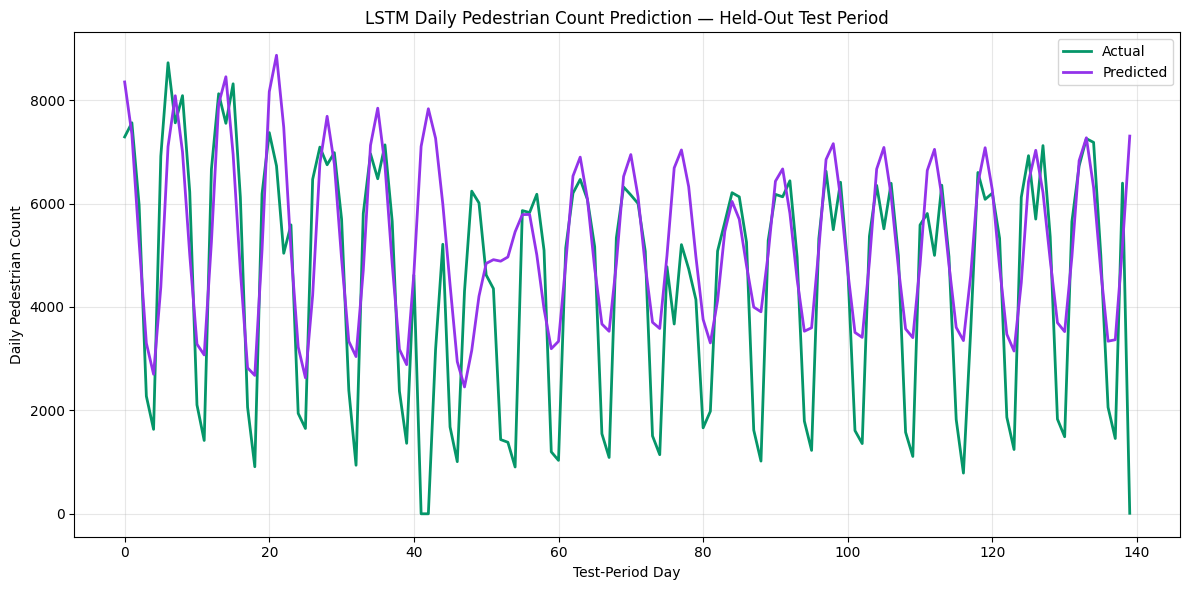

In [20]:
# Convert scaled test values and predictions back to pedestrian-count units.
y_test_inv = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred_lstm)

# Compare actual and predicted counts with the first two approved MOP colours.
plt.figure(figsize=(12, 6))
plt.plot(
    y_test_inv, label='Actual', linewidth=2, color=MOP_COLOURS[0]
)
plt.plot(
    y_pred_inv, label='Predicted', linewidth=2, color=MOP_COLOURS[1]
)
plt.title('LSTM Daily Pedestrian Count Prediction — Held-Out Test Period')
plt.xlabel('Test-Period Day')
plt.ylabel('Daily Pedestrian Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div class="usecase-body">
The predicted and actual pedestrian counts can be compared across the held-out period to assess how well the model follows changes in activity that it did not see during training. This helps determine whether historical pedestrian patterns alone provide useful information for anticipating future activity. Visual similarity should not be treated as sufficient evidence of forecasting accuracy, so numerical error metrics would be needed for a formal performance comparison.
</div>

<div class="usecase-unnumbered-heading"><b>Conclusion</b></div>
<div class="usecase-body">
This use case examines relationships between Melbourne microclimate conditions, pedestrian activity and tree canopy. The results highlight temporal and spatial patterns and show that environmental variables provide some predictive value for pedestrian activity. Findings should be interpreted as associations rather than causal effects due to differences in dataset coverage and sensor availability.
</div>

**What we achieved in this analysis**

This analysis established a reproducible workflow for loading and preparing City of Melbourne pedestrian, microclimate and tree-canopy datasets. Hourly pedestrian observations were aligned with microclimate measurements, spatial and temporal patterns were visualised, and Random Forest and LSTM models were used to examine predictive relationships in pedestrian activity.

**What we learned from this analysis**

The analysis shows that pedestrian activity and microclimate conditions vary across time and location. The Random Forest evaluation indicates how much predictive information is provided by air temperature, relative humidity, PM2.5 and noise, while SHAP values help identify which of these variables most influence individual predictions. The tree-canopy analysis provides a descriptive test of association between a grid-based canopy-density proxy and average air temperature. These findings describe associations and predictive patterns rather than causal effects.

**Observations for further opportunities**

Future work could improve spatial matching by linking individual pedestrian sensors with their nearest microclimate sensors and by measuring canopy area directly instead of using polygon counts as a density proxy. Additional variables such as rainfall, public holidays, major events and surrounding land use could also help explain pedestrian activity. Differences in dataset time coverage and the limited spatial distribution of microclimate sensors should be considered when interpreting the results.